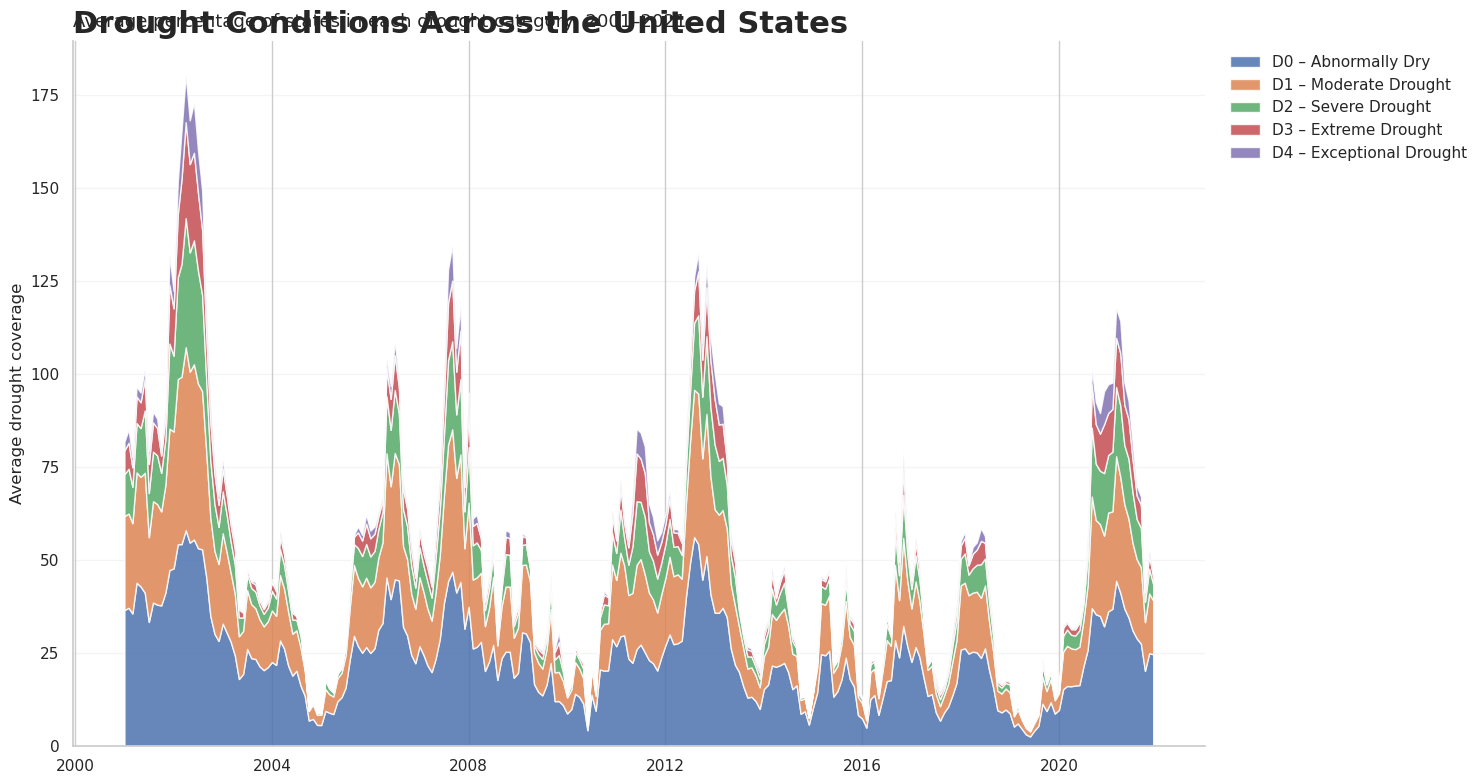

In [5]:
import pandas as pd
import matplotlib.pyplot as plt

# -----------------------------
# Load the TidyTuesday data
# -----------------------------
url = "https://raw.githubusercontent.com/rfordatascience/tidytuesday/main/data/2022/2022-06-14/drought.csv"

df = pd.read_csv(url)

# -----------------------------
# Convert DATE
# -----------------------------
# Values look like: d_18950101
df["DATE"] = pd.to_datetime(
    df["DATE"].str.replace("d_", "", regex=False),
    format="%Y%m%d"
)

# -----------------------------
# Calculate average drought
# across states
# -----------------------------
drought_cols = ["D0", "D1", "D2", "D3", "D4"]

national = (
    df.groupby("DATE")[drought_cols]
    .mean()
    .reset_index()
)

# -----------------------------
# Keep the 2001–2021 period
# -----------------------------
national = national[
    (national["DATE"] >= "2001-01-01") &
    (national["DATE"] <= "2021-12-31")
]

# -----------------------------
# Create chart
# -----------------------------
fig, ax = plt.subplots(figsize=(15, 8))

ax.stackplot(
    national["DATE"],
    national["D0"],
    national["D1"],
    national["D2"],
    national["D3"],
    national["D4"],
    labels=[
        "D0 – Abnormally Dry",
        "D1 – Moderate Drought",
        "D2 – Severe Drought",
        "D3 – Extreme Drought",
        "D4 – Exceptional Drought"
    ],
    alpha=0.85
)

# -----------------------------
# Titles
# -----------------------------
ax.set_title(
    "Drought Conditions Across the United States",
    fontsize=22,
    fontweight="bold",
    loc="left"
)

ax.text(
    0,
    1.02,
    "Average percentage of states in each drought category, 2001–2021",
    transform=ax.transAxes,
    fontsize=13
)

# -----------------------------
# Labels
# -----------------------------
ax.set_ylabel("Average drought coverage")
ax.set_xlabel("")

# -----------------------------
# Legend
# -----------------------------
ax.legend(
    loc="upper left",
    bbox_to_anchor=(1.01, 1),
    frameon=False
)

# -----------------------------
# Grid & styling
# -----------------------------
ax.grid(axis="y", alpha=0.2)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()